# Equilibrium Refinement Using CHEASE

This notebook demonstrates the VAFT CHEASE workflow adapter. The goal is to refine an initial EFIT GEQDSK equilibrium using the CHEASE inverse equilibrium code, then compare the original and refined profiles used by downstream stability workflows.

The workflow is self-contained up to input preparation. If a CHEASE executable is not available, or if CHEASE exits without producing a refined GEQDSK, the notebook reports the reason and keeps the diagnostic cells executable.


In [ ]:
from pathlib import Path
import os

# Resolve against the repository root, not the kernel's cwd: Jupyter starts
# in notebooks/, which would otherwise create a nested notebooks/notebooks/.
_repo_root = Path.cwd()
if _repo_root.name == "notebooks":
    _repo_root = _repo_root.parent
OUTPUT_DIR = Path(os.environ.get(
    "VAFT_DOCS_OUTPUT_DIR", _repo_root / "notebooks" / "outputs" / "docs"
))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Select the rendering backend explicitly. In a Jupyter kernel (Jupyter Lab,
# VS Code) ask for the inline backend rather than relying on ipykernel to
# preset MPLBACKEND, which older releases do not do. With no IPython at all
# (a plain `python` run) fall back to headless Agg -- export MPLBACKEND,
# e.g. MPLBACKEND=macosx, to get windows from a script instead.
try:
    _ipython = get_ipython()
except NameError:
    _ipython = None
if _ipython is None:
    os.environ.setdefault("MPLBACKEND", "Agg")
elif "IPKernelApp" in _ipython.config:
    _ipython.run_line_magic("matplotlib", "inline")

from pathlib import Path
import tempfile

import matplotlib.pyplot as plt
import numpy as np

import vaft
from vaft.data.resources import data_path
from vaft.data import read_geqdsk
from vaft.code.chease import (
    CHEASEConfig,
    collect_chease_outputs,
    find_chease_executable,
    prepare_chease_inputs,
    run_chease,
)

sample_path = data_path('efit/g039915.00319')
workdir = Path(tempfile.mkdtemp(prefix='vaft-chease-notebook-'))
config = CHEASEConfig(workdir=workdir, create_plot=True, cleanup=False, timeout=90)
print(f'Sample GEQDSK: {sample_path}')
print(f'CHEASE workdir: {workdir}')


Sample GEQDSK: <repo>/vaft/data/efit/g039915.00319
CHEASE workdir: <tmp>


## Load The Initial EFIT Equilibrium

The input can be a GEQDSK path, a `vaft.data.GEQDSK` object, or an OMAS ODS. The sample below uses a packaged GEQDSK file so that the notebook does not depend on a private database.


In [ ]:
initial = read_geqdsk(sample_path)
ods = initial.to_omas()
print(f"Grid: {initial['NW']} x {initial['NH']}")
print(f"Ip: {initial['CURRENT']:.6e} A")
print(f"B0: {initial['BCENTR']:.6e} T")
print(f"q range: {np.nanmin(initial['QPSI']):.3f} to {np.nanmax(initial['QPSI']):.3f}")


Grid: 129 x 129
Ip: 7.704014e+04 A
B0: 1.498059e-01 T
q range: 1.947 to 12.955


## Prepare CHEASE Inputs

`prepare_chease_inputs` materializes a run-directory GEQDSK, normalizes signs to CHEASE's COCOS-02 convention, and writes `EXPEQ` plus `chease_namelist`.


In [ ]:
inputs = prepare_chease_inputs(initial, config)
print('Prepared files:')
for path in inputs.files:
    print(f'  {path.name}: {path.stat().st_size} bytes')
for path in inputs.manifests:
    print(f'  manifest: {path.name}')
print('\nNamelist preview:')
print('\n'.join(inputs.namelist.read_text().splitlines()[:12]))


Prepared files:
  source.geqdsk: 284417 bytes
  input.geqdsk: 284417 bytes
  EXPEQ: 22430 bytes
  chease_namelist: 1507 bytes
  manifest: chease_cocos_transform.json

Namelist preview:
*************************
***    CHEASE NAMELIST FILE
***    namelist created by vaft.code.chease
*************************
&EQDATA
! --- CHEASE input file option
NOPT=0,
NSURF=6,
NEQDSK=0
TENSBND=    -0.1,
NSYM=0,
NTCASE=0,


## Run CHEASE When Available

CHEASE is an external Fortran executable. VAFT resolves `$CHEASEHOME/bin/chease`; existing `CHEASE` and `CHEASE_EXEC_DIR` installations remain supported when `CHEASEHOME` is unset. The notebook remains executable if no usable refined output is produced.


In [ ]:
executable = find_chease_executable(config)
print(f'Resolved CHEASE executable: {executable}')

result = None
if executable is None:
    print('CHEASE executable was not found. Skipping the run step.')
else:
    run_config = CHEASEConfig(
        executable=str(executable),
        workdir=workdir,
        target_psin=config.target_psin,
        relax=config.relax,
        nideal=config.nideal,
        nw=config.nw,
        auto_cocos=config.auto_cocos,
        output_cocos=config.output_cocos,
        preserve_boundary_limiter=config.preserve_boundary_limiter,
        create_plot=config.create_plot,
        cleanup=False,
        timeout=config.timeout,
    )
    result = run_chease(inputs, run_config)
    print(f'CHEASE return code interpreted by VAFT: {result.returncode}')
    print(f'Refined GEQDSK: {result.refined_geqdsk}')
    if not result.ok:
        print('CHEASE did not produce a valid refined GEQDSK in this environment.')
        if result.stderr.strip():
            print(result.stderr.strip())
        log_text = (workdir / 'chease.log').read_text(errors='replace') if (workdir / 'chease.log').exists() else ''
        print('\nLog tail:')
        print('\n'.join(log_text.splitlines()[-12:]))

if result is None:
    result = collect_chease_outputs(workdir, config)


Resolved CHEASE executable: ~/git/chease/src-f90/chease
CHEASE return code interpreted by VAFT: 1
Refined GEQDSK: None
CHEASE did not produce a valid refined GEQDSK in this environment.
             now will see if namelist given in file: 'chease_namelist'
  parameters not associated
 NITMOPT =            0
 after cotrol, output_flag =         -798
 there were problems in cotrol, quit chease
 ***********************************************************************
 in prog_new: there seem to have problems with chease: codeparam%output_flag =         -798
 see messages in output and may need to rerun with NVERBOSE=4 to have all info
 eqchease_out(1)%codeparam%output_diag(:):
in cotrol: see automatic message in chease output                                                                                   
                                                                                                                                    
                                                    

## Compare Original And Refined Profiles And Geometry

When a refined GEQDSK exists, the comparison overlays input and CHEASE-refined 1D profiles, normalized poloidal-flux contours in R-Z space, and boundary/limiter geometry. Otherwise, the cell displays the original equilibrium only and states that refinement output was unavailable.


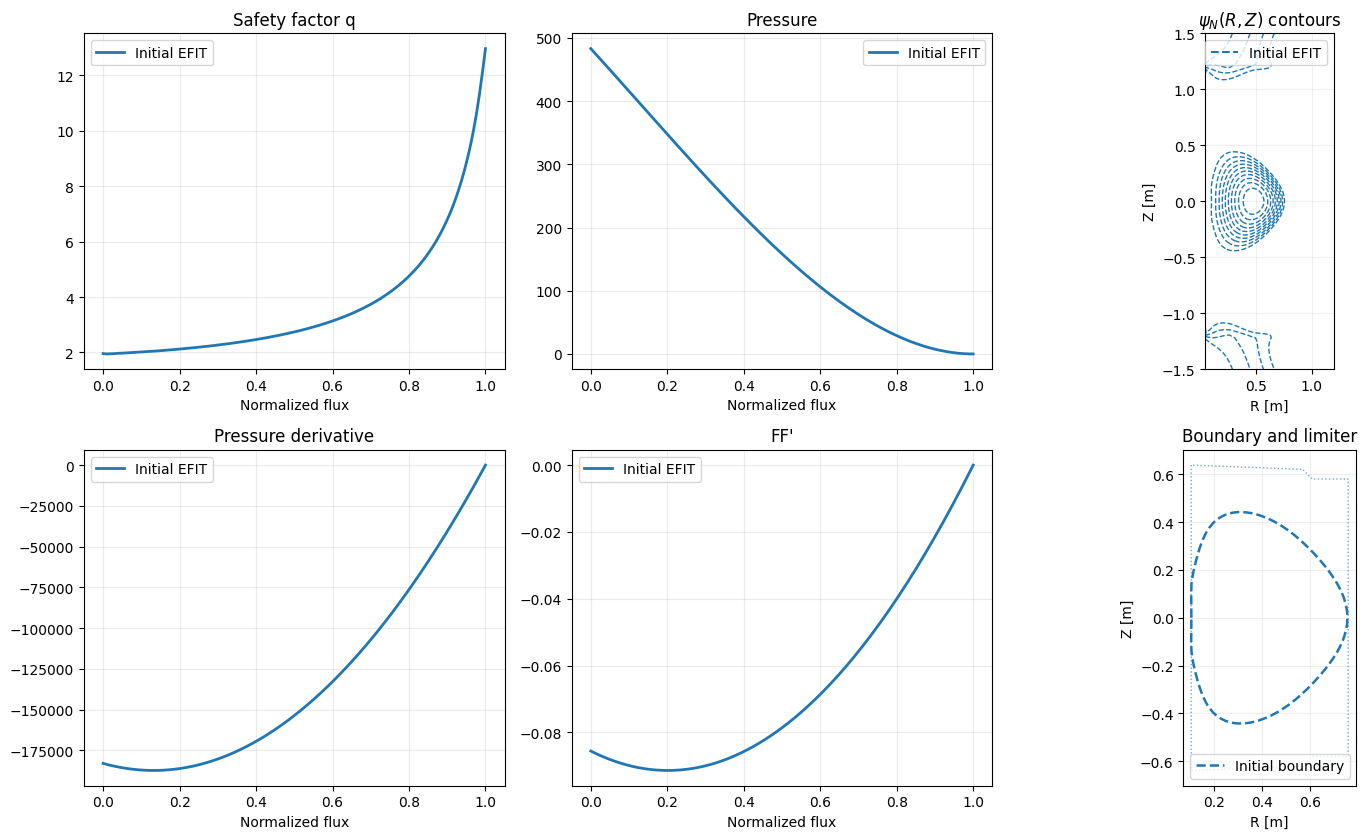

No refined GEQDSK is available; profile and geometry comparison is shown in initial-only mode.


In [ ]:
refined = read_geqdsk(result.refined_geqdsk) if result.refined_geqdsk else None
x0 = np.linspace(0.0, 1.0, initial['NW'])

fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
profiles = [
    ('QPSI', 'Safety factor q'),
    ('PRES', 'Pressure'),
    ('PPRIME', 'Pressure derivative'),
    ('FFPRIM', "FF'"),
]
for ax, (key, title) in zip([axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]], profiles):
    ax.plot(x0, np.asarray(initial[key], dtype=float), label='Initial EFIT', lw=2)
    if refined is not None:
        xr = np.linspace(0.0, 1.0, refined['NW'])
        ax.plot(xr, np.asarray(refined[key], dtype=float), label='CHEASE refined', lw=1.6)
    ax.set_title(title)
    ax.set_xlabel('Normalized flux')
    ax.grid(True, alpha=0.25)
    ax.legend()

def psi_norm_grid(geqdsk):
    nw, nh = int(geqdsk['NW']), int(geqdsk['NH'])
    r = np.linspace(float(geqdsk['RLEFT']), float(geqdsk['RLEFT']) + float(geqdsk['RDIM']), nw)
    z = np.linspace(
        float(geqdsk['ZMID']) - float(geqdsk['ZDIM']) / 2.0,
        float(geqdsk['ZMID']) + float(geqdsk['ZDIM']) / 2.0,
        nh,
    )
    psi = np.asarray(geqdsk['PSIRZ'], dtype=float).reshape(nw, nh)
    denom = float(geqdsk['SIBRY']) - float(geqdsk['SIMAG'])
    psi_n = np.zeros_like(psi) if abs(denom) < 1e-30 else (psi - float(geqdsk['SIMAG'])) / denom
    return r, z, psi_n

r0, z0, psi0 = psi_norm_grid(initial)
levels = np.linspace(0.1, 1.0, 10)
ax_psi = axes[0, 2]
ax_psi.contour(r0, z0, psi0.T, levels=levels, colors='tab:blue', linewidths=1.0, linestyles='--')
ax_psi.plot([], [], '--', color='tab:blue', label='Initial EFIT')
if refined is not None:
    rr, zr, psir = psi_norm_grid(refined)
    ax_psi.contour(rr, zr, psir.T, levels=levels, colors='tab:orange', linewidths=1.0)
    ax_psi.plot([], [], '-', color='tab:orange', label='CHEASE refined')
ax_psi.set_title(r'$\psi_N(R,Z)$ contours')
ax_psi.set_xlabel('R [m]')
ax_psi.set_ylabel('Z [m]')
ax_psi.set_aspect('equal', adjustable='box')
ax_psi.grid(True, alpha=0.2)
ax_psi.legend()

ax_bnd = axes[1, 2]
for item, color, label, linestyle in [
    (initial, 'tab:blue', 'Initial boundary', '--'),
    (refined, 'tab:orange', 'CHEASE boundary', '-'),
]:
    if item is None:
        continue
    rb = np.asarray(item.get('RBBBS', []), dtype=float)
    zb = np.asarray(item.get('ZBBBS', []), dtype=float)
    if rb.size and zb.size:
        count = min(rb.size, zb.size)
        ax_bnd.plot(rb[:count], zb[:count], color=color, linestyle=linestyle, lw=1.8, label=label)
    rl = np.asarray(item.get('RLIM', []), dtype=float)
    zl = np.asarray(item.get('ZLIM', []), dtype=float)
    if rl.size and zl.size:
        count = min(rl.size, zl.size)
        ax_bnd.plot(rl[:count], zl[:count], color=color, linestyle=':', lw=1.0, alpha=0.65)
ax_bnd.set_title('Boundary and limiter')
ax_bnd.set_xlabel('R [m]')
ax_bnd.set_ylabel('Z [m]')
ax_bnd.set_aspect('equal', adjustable='box')
ax_bnd.grid(True, alpha=0.2)
ax_bnd.legend()

fig.tight_layout()
plt.show()

if refined is None:
    print('No refined GEQDSK is available; profile and geometry comparison is shown in initial-only mode.')
else:
    print('Comparison metrics:')
    for key, value in result.comparison.items():
        print(f'  {key}: {value:.6g}')


## Workflow Outputs

The generated files are intentionally kept in a temporary work directory for inspection. Downstream workflows can use `result.refined_geqdsk` when it is available, or inspect `result.logs` and manifest files when CHEASE does not converge.


In [ ]:
print('Workdir contents:')
for path in sorted(workdir.iterdir()):
    print(f'  {path.name:40s} {path.stat().st_size:10d} bytes')
print('\nResult summary:')
print(f'  ok: {result.ok}')
print(f'  logs: {[p.name for p in result.logs]}')
print(f'  manifests: {[p.name for p in result.manifests]}')
print(f'  figures: {[p.name for p in result.figures]}')


Workdir contents:
  EXPEQ                                         22430 bytes
  chease.log                                     9307 bytes
  chease_cocos_transform.json                    1140 bytes
  chease_namelist                                1507 bytes
  input.geqdsk                                 284417 bytes
  source.geqdsk                                284417 bytes

Result summary:
  ok: False
  logs: ['chease.log']
  manifests: ['chease_cocos_transform.json']
  figures: []


In [ ]:
fig.savefig(OUTPUT_DIR / "equilibrium-inputs.png", dpi=180, bbox_inches="tight")
readiness = {
    "sample": str(sample_path),
    "prepared_files": [path.name for path in inputs.files],
    "chease_executable": str(executable) if executable else None,
    "execution_mode": "external-binary" if executable else "input-preparation",
}
import json
(OUTPUT_DIR / "equilibrium-readiness.txt").write_text(json.dumps(readiness, indent=2) + "\n")
print(readiness)

{'sample': '<repo>/vaft/data/efit/g039915.00319', 'prepared_files': ['source.geqdsk', 'input.geqdsk', 'EXPEQ', 'chease_namelist'], 'chease_executable': '~/git/chease/src-f90/chease', 'execution_mode': 'external-binary'}
